Código 303: Diagnóstico de Variables de Contexto y Sesgo Jurisprudencial

Este código debe ejecutarse en tu infraestructura de VS Code. Utiliza operaciones vectorizadas de Pandas y visualización de grado científico con Seaborn.

--- DISTRIBUCIÓN DE MERCADO POR TIPO DE ASEGURADOR ---
Carrier Type
1A. PRIVATE                                     47.852549
2A. SIF                                         21.127954
3A. SELF PUBLIC                                 19.303514
4A. SELF PRIVATE                                10.465009
UNKNOWN                                          0.565591
5A. SPECIAL FUND - CONS. COMM. (SECT. 25-A)      0.521216
5D. SPECIAL FUND - UNKNOWN                       0.161789
5C. SPECIAL FUND - POI CARRIER WCB MENANDS       0.001300
2B. ATF                                          0.000762
5B. SPECIAL FUND - CONS. COMM. (SECT. 15-8))     0.000316
Name: proportion, dtype: float64


C:\Users\julia\AppData\Local\Temp\ipykernel_154488\2986797812.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=carrier_dist.values, y=carrier_dist.index, palette='magma')


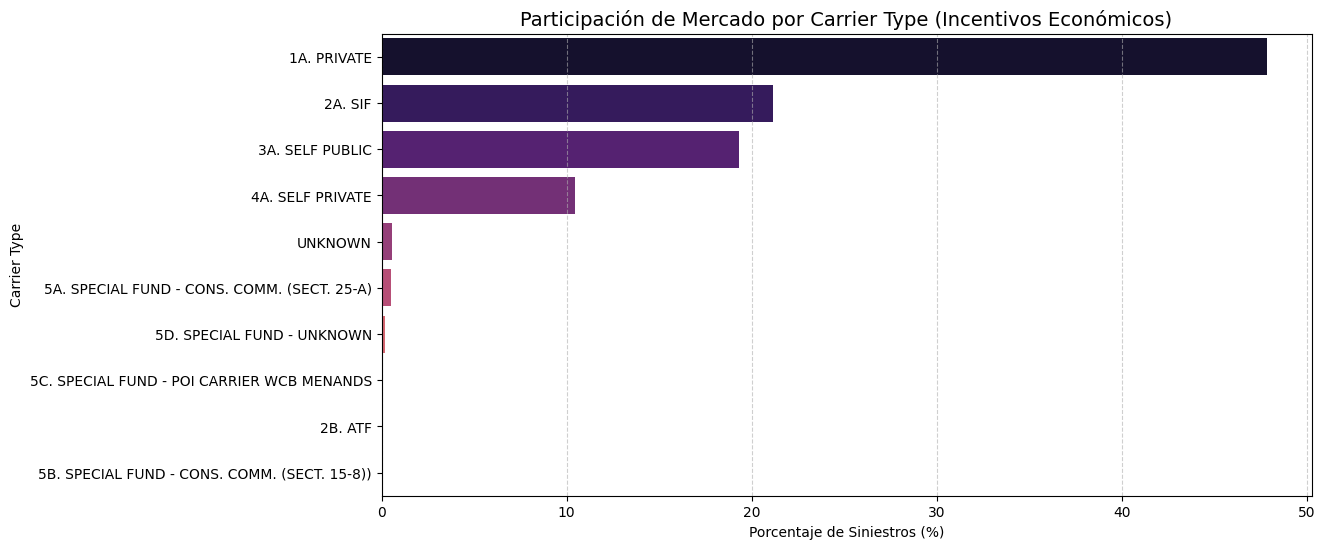

C:\Users\julia\AppData\Local\Temp\ipykernel_154488\2986797812.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='District Name',


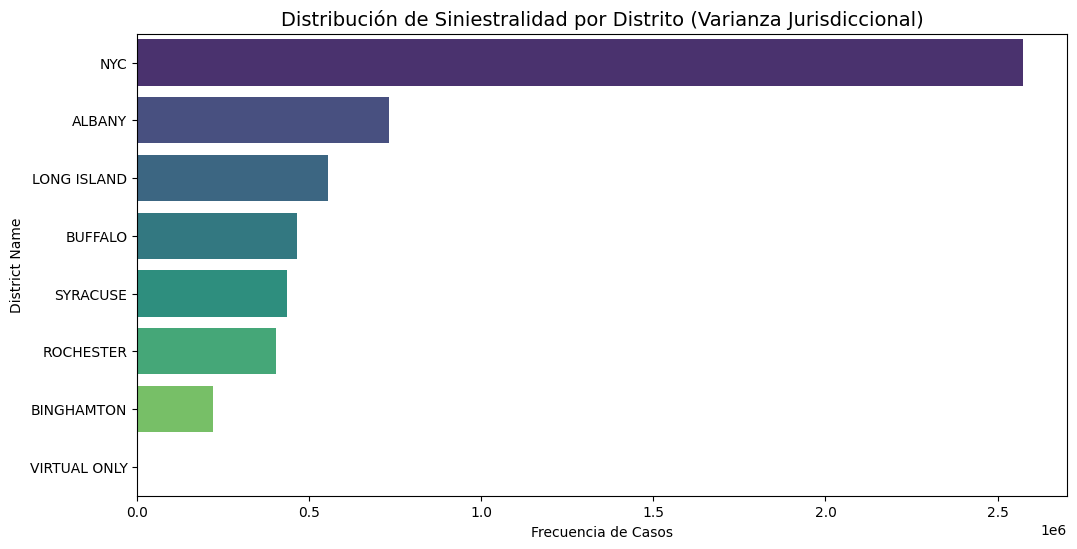

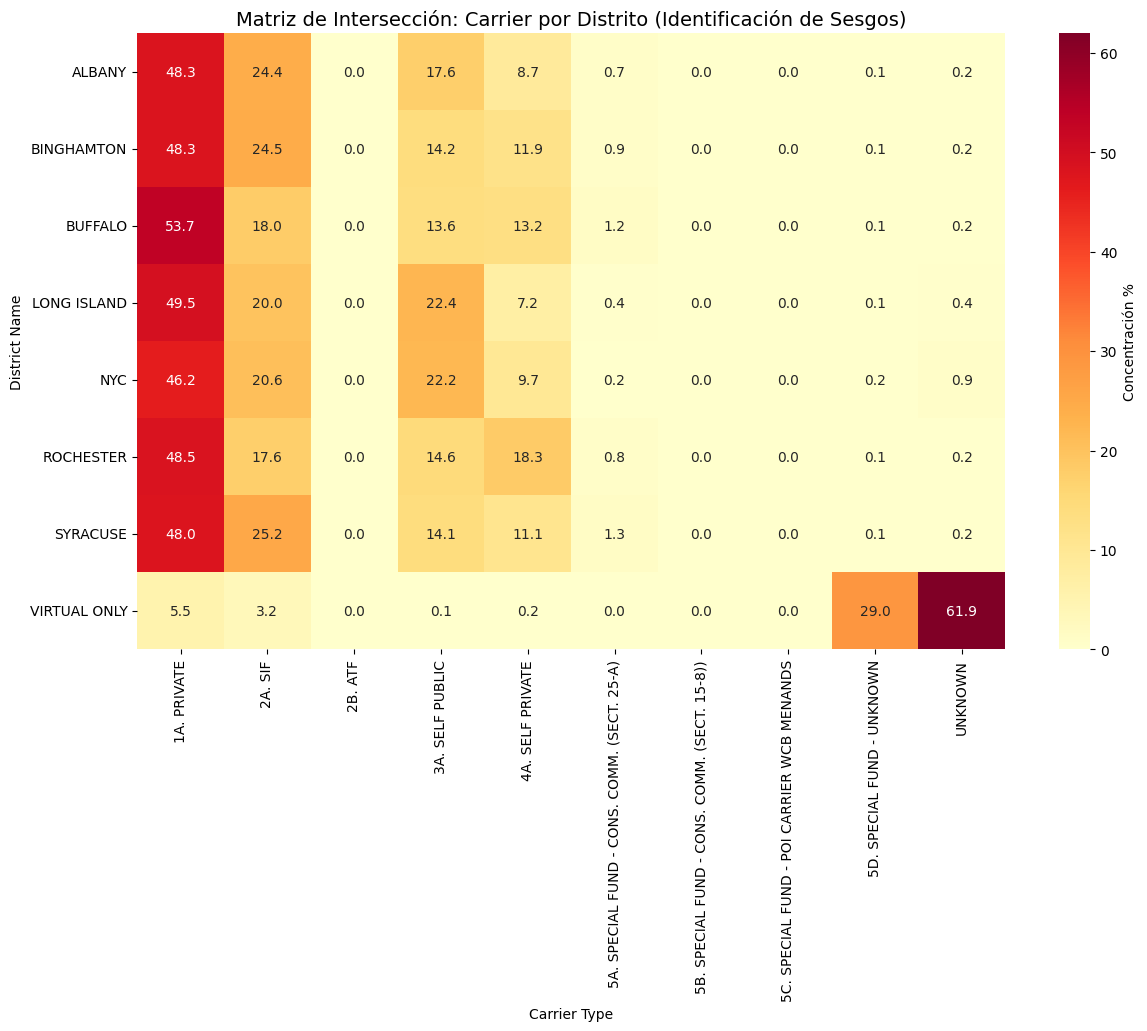

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ===========================================================================
# 303.1 CARGA Y SANEAMIENTO DE CABECERAS (PROCEDIMIENTO ESTÁNDAR)
# ===========================================================================
# Cargamos el dataset. Ajustar la ruta según su infraestructura local.
path_raw = r'C:\Tesis_ML\raw_data\nyswcb_claims.csv'
df = pd.read_csv(path_raw, low_memory=False)

# Aplicamos la limpieza de strings para asegurar trazabilidad absoluta [cite: 9]
df.columns = [c.strip().replace('\r', '').replace('\n', '') for c in df.columns]

# ===========================================================================
# 303.2 ANÁLISIS DE CONCENTRACIÓN DE MERCADO (CARRIER TYPE)
# ===========================================================================
# El Carrier Type define la estructura de incentivos económicos [cite: 71, 75]
carrier_dist = df['Carrier Type'].value_counts(normalize=True) * 100

print("--- DISTRIBUCIÓN DE MERCADO POR TIPO DE ASEGURADOR ---")
print(carrier_dist)

plt.figure(figsize=(12, 6))
sns.barplot(x=carrier_dist.values, y=carrier_dist.index, palette='magma')
plt.title('Participación de Mercado por Carrier Type (Incentivos Económicos)', fontsize=14)
plt.xlabel('Porcentaje de Siniestros (%)')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

# ===========================================================================
# 303.3 ANÁLISIS DE CLIMA LEGAL (DISTRICT NAME)
# ===========================================================================
# El Distrito captura la varianza jurisdiccional [cite: 77, 79]
district_dist = df['District Name'].value_counts(normalize=True) * 100

plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='District Name', 
              order=df['District Name'].value_counts().index, 
              palette='viridis')
plt.title('Distribución de Siniestralidad por Distrito (Varianza Jurisdiccional)', fontsize=14)
plt.xlabel('Frecuencia de Casos')
plt.show()

# ===========================================================================
# 303.4 MAPA DE CALOR: INTERSECCIÓN CARRIER VS DISTRITO
# ===========================================================================
# Buscamos identificar sesgos por la combinación de actor y zona [cite: 81, 82]
cross_analysis = pd.crosstab(df['District Name'], df['Carrier Type'], normalize='index') * 100

plt.figure(figsize=(14, 8))
sns.heatmap(cross_analysis, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={'label': 'Concentración %'})
plt.title('Matriz de Intersección: Carrier por Distrito (Identificación de Sesgos)', fontsize=14)
plt.show()